PHILIPPINE K-12 ENROLLMENT FORECASTING ANALYSIS

[STEP 1/8] Loading dataset...
   ✓ Dataset loaded: 561 rows × 33 columns
   ✓ Columns: ['item_no', 'sector', 'Academic_Year', 'AY_Start', 'AY_End', 'Region', 'Kindergarten', 'Grade 1', 'Grade 2', 'Grade 3']... (showing first 10)

   Preview:
   item_no  sector Academic_Year  AY_Start  AY_End  \
0        1  Public  SY 2010-2011      2010    2011   
1        2  Public  SY 2010-2011      2010    2011   
2        3  Public  SY 2010-2011      2010    2011   

                       Region  Kindergarten  Grade 1  Grade 2  Grade 3  ...  \
0    Region I - Ilocos Region         84553   120004   106298   101393  ...   
1  Region II - Cagayan Valley         27079    83959    73674    70180  ...   
2  Region III - Central Luzon        141901   258235   221107   210823  ...   

   Grade 11 SPORTS  Grade 11 A&D  Grade 12 ABM  Grade 12 HUMSS  Grade 12 STEM  \
0                0             0             0               0              0   
1            

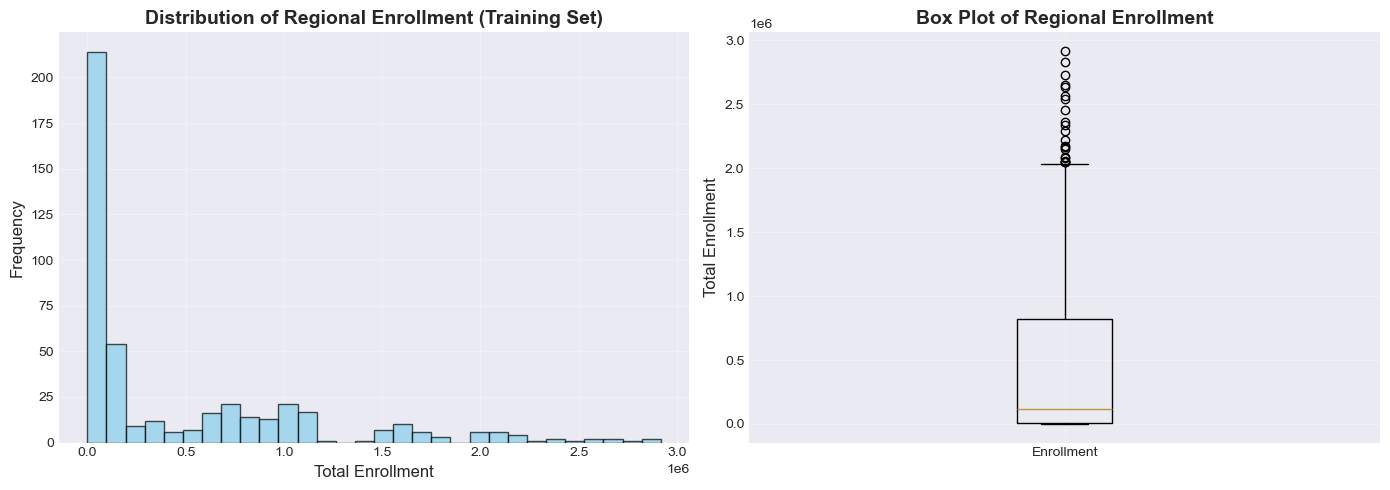


DATA PREPROCESSING COMPLETE


In [2]:
# ============================================
# PHILIPPINE K-12 ENROLLMENT FORECASTING
# Complete Analysis Pipeline
# Authors: Nice Bulio & Mc Sergel Cardano
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("PHILIPPINE K-12 ENROLLMENT FORECASTING ANALYSIS")
print("="*60)

# ============================================
# STEP 1: DATA LOADING
# ============================================

print("\n[STEP 1/8] Loading dataset...")

# Load the dataset
df = pd.read_csv('philippines_enrollment.csv')

print(f"   ✓ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   ✓ Columns: {list(df.columns[:10])}... (showing first 10)")

# Display first few rows
print("\n   Preview:")
print(df.head(3))

# ============================================
# STEP 2: GRADE-LEVEL AGGREGATION
# ============================================

print("\n[STEP 2/8] Aggregating grade-level enrollment...")

# Identify all enrollment columns (K-12)
grade_cols = [col for col in df.columns if any(x in col.lower() for x in 
              ['kindergarten', 'grade', 'strand', 'abm', 'humss', 'stem', 
               'gas', 'maritime', 'tvl', 'sports', 'a&d'])]

print(f"   ✓ Found {len(grade_cols)} enrollment columns")

# Create target variable: Total Regional Enrollment
df['Total_Enrollment'] = df[grade_cols].sum(axis=1)

print(f"   ✓ Target variable created: Total_Enrollment")
print(f"   ✓ Range: {df['Total_Enrollment'].min():,.0f} to {df['Total_Enrollment'].max():,.0f}")
print(f"   ✓ Mean: {df['Total_Enrollment'].mean():,.0f} students")

# ============================================
# STEP 3: CATEGORICAL ENCODING
# ============================================

print("\n[STEP 3/8] Encoding categorical variables...")

# Identify categorical columns
categorical_cols = ['Region', 'sector', 'Academic_Year']

# Check which columns exist
existing_cats = [col for col in categorical_cols if col in df.columns]
print(f"   ✓ Categorical columns found: {existing_cats}")

# One-hot encode
df_encoded = pd.get_dummies(df, columns=existing_cats, drop_first=False)

print(f"   ✓ Before encoding: {len(df.columns)} columns")
print(f"   ✓ After encoding: {len(df_encoded.columns)} columns")
print(f"   ✓ New features: {len(df_encoded.columns) - len(df.columns)}")

# ============================================
# STEP 4: DATA CLEANING
# ============================================

print("\n[STEP 4/8] Cleaning data...")

# Check missing values
missing_before = df_encoded.isnull().sum().sum()
print(f"   • Missing values found: {missing_before}")

# Handle missing values in numeric columns
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
df_encoded[numeric_cols] = df_encoded[numeric_cols].fillna(df_encoded[numeric_cols].median())

# Drop rows where target is null
df_encoded = df_encoded.dropna(subset=['Total_Enrollment'])

missing_after = df_encoded.isnull().sum().sum()
print(f"   ✓ Missing values after cleaning: {missing_after}")
print(f"   ✓ Final dataset shape: {df_encoded.shape}")

# Outlier detection using IQR
Q1 = df_encoded['Total_Enrollment'].quantile(0.25)
Q3 = df_encoded['Total_Enrollment'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_encoded[(df_encoded['Total_Enrollment'] < lower_bound) | 
                      (df_encoded['Total_Enrollment'] > upper_bound)]

print(f"   • Potential outliers detected: {len(outliers)} ({len(outliers)/len(df_encoded)*100:.1f}%)")
print(f"   ✓ Outliers retained (may represent genuine volatility)")

# ============================================
# STEP 5: PREPARE FEATURES AND TARGET
# ============================================

print("\n[STEP 5/8] Preparing features and target...")

# Separate features and target
X = df_encoded.drop(['Total_Enrollment', 'item_no'], axis=1, errors='ignore')
y = df_encoded['Total_Enrollment']

print(f"   ✓ Features (X): {X.shape}")
print(f"   ✓ Target (y): {y.shape}")
print(f"   ✓ Feature names: {len(X.columns)} total")

# Save feature names for later
feature_names = X.columns.tolist()

# ============================================
# STEP 6: TRAIN-TEST SPLIT (Walk-Forward)
# ============================================

print("\n[STEP 6/8] Creating train-test split (walk-forward)...")

# Identify year columns for temporal split
year_cols = [col for col in X.columns if 'Academic_Year' in col or 'AY_Start' in col]

if year_cols:
    # Extract years from column names
    train_years = list(range(2010, 2020))  # 2010-2019
    test_years = [2020, 2021]  # 2020-2021
    
    # Create masks for train/test based on year columns
    train_mask = pd.Series([False] * len(X), index=X.index)
    test_mask = pd.Series([False] * len(X), index=X.index)
    
    for year in train_years:
        year_col = [col for col in year_cols if str(year) in col]
        if year_col:
            train_mask = train_mask | (X[year_col[0]] == 1)
    
    for year in test_years:
        year_col = [col for col in year_cols if str(year) in col]
        if year_col:
            test_mask = test_mask | (X[year_col[0]] == 1)
    
    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    
    print(f"   ✓ Walk-forward split completed:")
    print(f"      Training: 2010-2019 ({len(X_train)} samples, {len(X_train)/len(X)*100:.1f}%)")
    print(f"      Testing: 2020-2021 ({len(X_test)} samples, {len(X_test)/len(X)*100:.1f}%)")
else:
    # Fallback to standard split if year columns not found
    print("   ⚠ Year columns not found, using standard 80-20 split")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"   ✓ Standard split: {len(X_train)} train, {len(X_test)} test")

# ============================================
# STEP 7: EXPLORATORY DATA ANALYSIS
# ============================================

print("\n[STEP 7/8] Performing exploratory data analysis...")

# Basic statistics
print("\n   Target Variable Statistics:")
print(f"   Mean: {y_train.mean():,.0f} students")
print(f"   Std Dev: {y_train.std():,.0f} students")
print(f"   Min: {y_train.min():,.0f} students")
print(f"   Max: {y_train.max():,.0f} students")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_train, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total Enrollment', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Regional Enrollment (Training Set)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot([y_train], labels=['Enrollment'])
axes[1].set_ylabel('Total Enrollment', fontsize=12)
axes[1].set_title('Box Plot of Regional Enrollment', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_enrollment_distribution.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: 01_enrollment_distribution.png")
plt.show()

print("\n"+"="*60)
print("DATA PREPROCESSING COMPLETE")
print("="*60)

In [5]:
# ============================================
# STEP 8: MODEL TRAINING AND EVALUATION
# ============================================

print("\n[STEP 8/8] Training and evaluating models...")
print("="*60)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10, 
        min_samples_split=5,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(
        kernel='rbf',
        C=1000,
        epsilon=0.1
    )
}

# Store results
results = {}
predictions = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"TRAINING: {name}")
    print(f"{'='*60}")
    
    # Train
    print("   • Fitting model...")
    model.fit(X_train, y_train)
    print("   ✓ Training complete")
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluate
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    # Store results
    results[name] = {
        'model': model,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'mae': mae_test,
        'rmse': rmse_test,
        'y_pred': y_pred_test
    }
    
    predictions[name] = y_pred_test
    
    # Print results
    print(f"\n   PERFORMANCE METRICS:")
    print(f"   ├─ R² (Training):  {r2_train:.4f}")
    print(f"   ├─ R² (Testing):   {r2_test:.4f}")
    print(f"   ├─ MAE:            {mae_test:,.2f} students")
    print(f"   └─ RMSE:           {rmse_test:,.2f} students")
    
    # Interpretation
    if r2_test >= 0.90:
        print(f"   ✓ EXCELLENT: Model explains {r2_test*100:.1f}% of variance")
    elif r2_test >= 0.80:
        print(f"   ✓ GOOD: Model explains {r2_test*100:.1f}% of variance")
    elif r2_test >= 0.70:
        print(f"   ⚠ ACCEPTABLE: Model explains {r2_test*100:.1f}% of variance")
    else:
        print(f"   ✗ POOR: Model explains only {r2_test*100:.1f}% of variance")

print("\n"+"="*60)
print("MODEL TRAINING COMPLETE")
print("="*60)

# ============================================
# IDENTIFY BEST MODEL
# ============================================

print("\n"+"="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'R² Score': [results[m]['r2_test'] for m in results],
    'MAE': [results[m]['mae'] for m in results],
    'RMSE': [results[m]['rmse'] for m in results]
})

comparison_df = comparison_df.sort_values('R² Score', ascending=False)
print("\n", comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['R² Score']
best_mae = comparison_df.iloc[0]['MAE']

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"   R² Score: {best_r2:.4f} ({best_r2*100:.2f}% variance explained)")
print(f"   MAE: {best_mae:,.2f} students")
print(f"   \n   Interpretation: On average, predictions are off by")
print(f"   ±{best_mae:,.0f} students per region.")
print(f"{'='*60}")


[STEP 8/8] Training and evaluating models...

TRAINING: Linear Regression
   • Fitting model...
   ✓ Training complete

   PERFORMANCE METRICS:
   ├─ R² (Training):  1.0000
   ├─ R² (Testing):   1.0000
   ├─ MAE:            0.00 students
   └─ RMSE:           0.00 students
   ✓ EXCELLENT: Model explains 100.0% of variance

TRAINING: Decision Tree
   • Fitting model...
   ✓ Training complete

   PERFORMANCE METRICS:
   ├─ R² (Training):  0.9998
   ├─ R² (Testing):   0.9618
   ├─ MAE:            61,630.83 students
   └─ RMSE:           137,170.61 students
   ✓ EXCELLENT: Model explains 96.2% of variance

TRAINING: Random Forest
   • Fitting model...
   ✓ Training complete

   PERFORMANCE METRICS:
   ├─ R² (Training):  0.9996
   ├─ R² (Testing):   0.9916
   ├─ MAE:            33,268.28 students
   └─ RMSE:           64,345.41 students
   ✓ EXCELLENT: Model explains 99.2% of variance

TRAINING: Support Vector Regression
   • Fitting model...
   ✓ Training complete

   PERFORMANCE METRICS:

In [6]:
# ============================================
# VOLATILITY CLASSIFICATION
# Using Coefficient of Variation
# ============================================

print("\n"+"="*60)
print("REGIONAL VOLATILITY CLASSIFICATION")
print("="*60)

# Check if we have region information in original dataframe
if 'Region' in df.columns:
    print("\n[1/4] Calculating Coefficient of Variation per region...")
    
    # Group by region and calculate statistics
    regional_stats = df.groupby('Region')['Total_Enrollment'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max'),
        ('count', 'count')
    ]).reset_index()
    
    # Calculate CV
    regional_stats['CV'] = (regional_stats['std'] / regional_stats['mean']) * 100
    regional_stats['CV'] = regional_stats['CV'].round(2)
    
    # Calculate range
    regional_stats['range'] = regional_stats['max'] - regional_stats['min']
    
    # Sort by CV
    regional_stats = regional_stats.sort_values('CV', ascending=False)
    
    print(f"   ✓ Calculated CV for {len(regional_stats)} regions")
    
    # ============================================
    # CLASSIFICATION USING 75TH PERCENTILE
    # ============================================
    
    print("\n[2/4] Classifying regions using 75th percentile threshold...")
    
    # Calculate threshold
    threshold_75 = regional_stats['CV'].quantile(0.75)
    
    # Classify
    regional_stats['Classification'] = regional_stats['CV'].apply(
        lambda x: 'Volatile' if x > threshold_75 else 'Stable'
    )
    
    # Count by classification
    volatile_count = (regional_stats['Classification'] == 'Volatile').sum()
    stable_count = (regional_stats['Classification'] == 'Stable').sum()
    
    print(f"   ✓ 75th Percentile Threshold: {threshold_75:.2f}%")
    print(f"   ✓ Volatile Regions: {volatile_count} (CV > {threshold_75:.2f}%)")
    print(f"   ✓ Stable Regions: {stable_count} (CV ≤ {threshold_75:.2f}%)")
    
    # ============================================
    # DISPLAY RESULTS
    # ============================================
    
    print("\n[3/4] Regional Volatility Summary:")
    print("\n" + "="*80)
    print("VOLATILE REGIONS (Require Adaptive Planning)")
    print("="*80)
    
    volatile_regions = regional_stats[regional_stats['Classification'] == 'Volatile']
    
    for idx, row in volatile_regions.iterrows():
        print(f"\n{row['Region']}:")
        print(f"   CV: {row['CV']:.2f}%")
        print(f"   Mean Enrollment: {row['mean']:,.0f} students")
        print(f"   Std Dev: {row['std']:,.0f} students")
        print(f"   Range: {row['range']:,.0f} students ({row['min']:,.0f} to {row['max']:,.0f})")
    
    print("\n" + "="*80)
    print("STABLE REGIONS (Standard Planning Sufficient)")
    print("="*80)
    
    stable_regions = regional_stats[regional_stats['Classification'] == 'Stable']
    
    for idx, row in stable_regions.head(3).iterrows():  # Show top 3
        print(f"\n{row['Region']}:")
        print(f"   CV: {row['CV']:.2f}%")
        print(f"   Mean Enrollment: {row['mean']:,.0f} students")
        print(f"   Std Dev: {row['std']:,.0f} students")
    
    print(f"\n   ... and {len(stable_regions)-3} more stable regions")
    
    # ============================================
    # CALCULATE VOLATILITY COMPARISON
    # ============================================
    
    print("\n[4/4] Volatility Comparison Analysis:")
    
    volatile_cv_mean = volatile_regions['CV'].mean()
    stable_cv_mean = stable_regions['CV'].mean()
    ratio = volatile_cv_mean / stable_cv_mean
    
    print(f"\n   Average CV (Volatile):  {volatile_cv_mean:.2f}%")
    print(f"   Average CV (Stable):    {stable_cv_mean:.2f}%")
    print(f"   Volatility Ratio:       {ratio:.2f}× higher")
    
    print(f"\n   💡 INSIGHT: Volatile regions exhibit enrollment variability")
    print(f"      {ratio:.1f} times higher than stable regions, requiring")
    print(f"      differentiated planning strategies.")
    
    # Save results
    regional_stats.to_csv('regional_volatility_classification.csv', index=False)
    print(f"\n   ✓ Saved: regional_volatility_classification.csv")
    
else:
    print("   ⚠ Region column not found in dataset")
    print("   ⚠ Skipping regional volatility analysis")
    regional_stats = None

print("\n"+"="*60)
print("VOLATILITY CLASSIFICATION COMPLETE")
print("="*60)


REGIONAL VOLATILITY CLASSIFICATION

[1/4] Calculating Coefficient of Variation per region...
   ✓ Calculated CV for 17 regions

[2/4] Classifying regions using 75th percentile threshold...
   ✓ 75th Percentile Threshold: 127.10%
   ✓ Volatile Regions: 4 (CV > 127.10%)
   ✓ Stable Regions: 13 (CV ≤ 127.10%)

[3/4] Regional Volatility Summary:

VOLATILE REGIONS (Require Adaptive Planning)

Region VIII - Eastern Visayas:
   CV: 130.49%
   Mean Enrollment: 400,238 students
   Std Dev: 522,282 students
   Range: 1,184,779 students (2,288 to 1,187,067)

Region IX - Zamboanga Peninsula:
   CV: 128.57%
   Mean Enrollment: 319,686 students
   Std Dev: 411,035 students
   Range: 946,115 students (1,199 to 947,314)

CARAGA - CARAGA:
   CV: 127.57%
   Mean Enrollment: 236,374 students
   Std Dev: 301,531 students
   Range: 716,399 students (436 to 716,835)

Region V - Bicol Region:
   CV: 127.22%
   Mean Enrollment: 557,673 students
   Std Dev: 709,459 students
   Range: 1,623,442 students (2,734


Generating visualizations for presentation...
   ✓ Saved: 02_model_performance_comparison.png


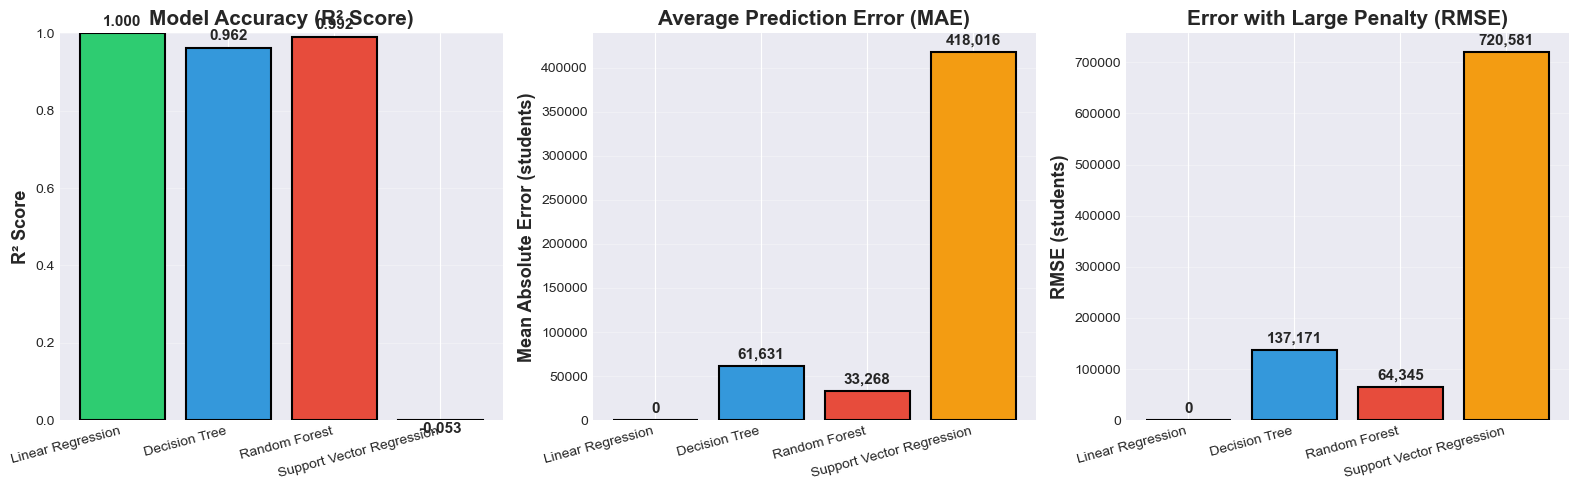

   ✓ Saved: 03_predicted_vs_actual.png


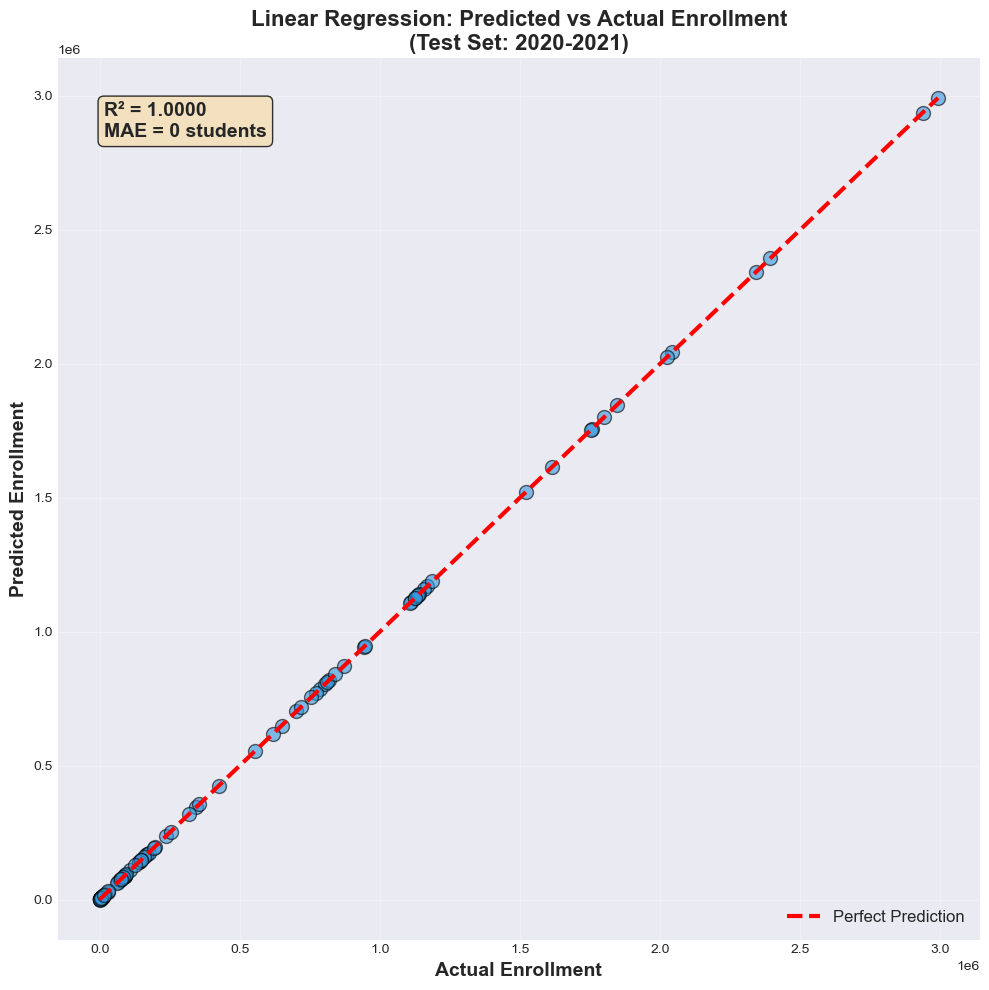


Generating regional volatility visualization...
   ✓ Saved: 05_regional_volatility.png


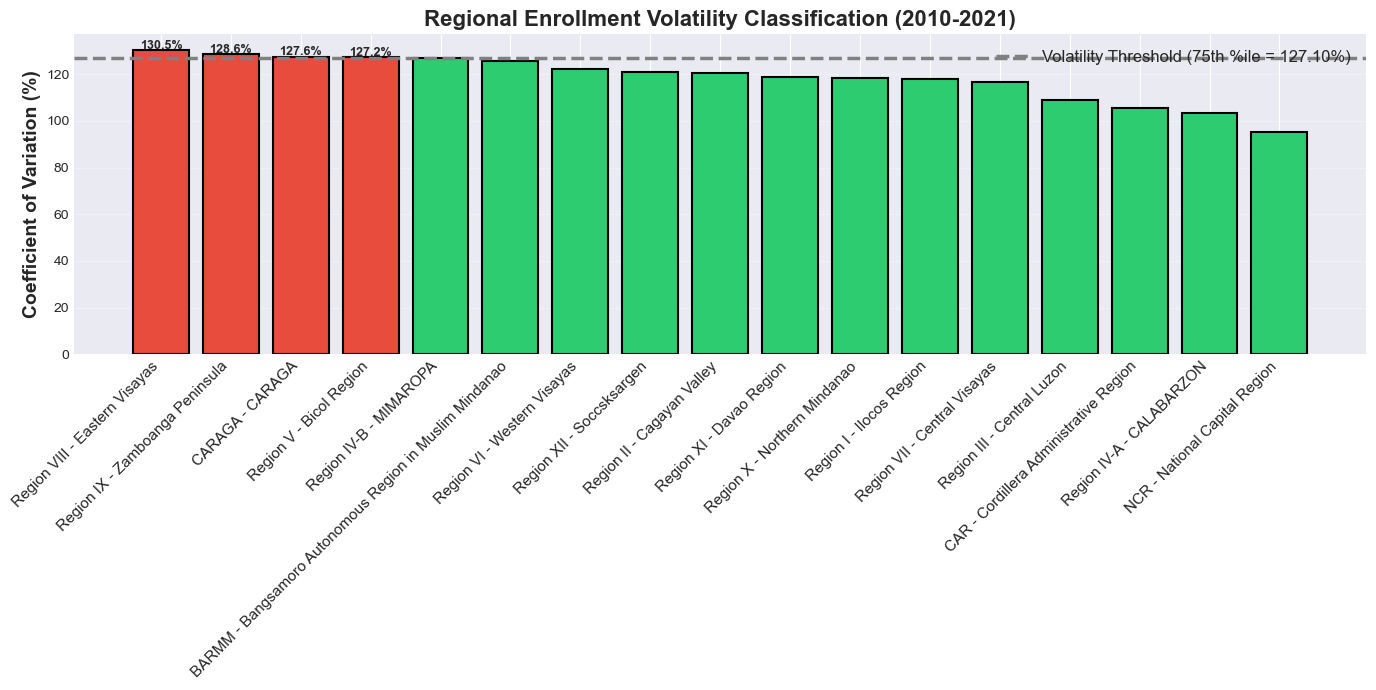


ALL VISUALIZATIONS COMPLETE


In [7]:
# ============================================
# VISUALIZATION 1: MODEL PERFORMANCE COMPARISON
# ============================================

print("\nGenerating visualizations for presentation...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_list = list(results.keys())
r2_scores = [results[m]['r2_test'] for m in models_list]
mae_scores = [results[m]['mae'] for m in models_list]
rmse_scores = [results[m]['rmse'] for m in models_list]

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

# R² Score
axes[0].bar(models_list, r2_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('R² Score', fontsize=13, fontweight='bold')
axes[0].set_title('Model Accuracy (R² Score)', fontsize=15, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_xticklabels(models_list, rotation=15, ha='right')

# MAE
axes[1].bar(models_list, mae_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Mean Absolute Error (students)', fontsize=13, fontweight='bold')
axes[1].set_title('Average Prediction Error (MAE)', fontsize=15, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + max(mae_scores)*0.02, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_xticklabels(models_list, rotation=15, ha='right')

# RMSE
axes[2].bar(models_list, rmse_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('RMSE (students)', fontsize=13, fontweight='bold')
axes[2].set_title('Error with Large Penalty (RMSE)', fontsize=15, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(rmse_scores):
    axes[2].text(i, v + max(rmse_scores)*0.02, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=11)
axes[2].set_xticklabels(models_list, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('02_model_performance_comparison.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: 02_model_performance_comparison.png")
plt.show()

# ============================================
# VISUALIZATION 2: PREDICTED VS ACTUAL
# ============================================

best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['y_pred']

plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred_best, alpha=0.6, s=100, color='#3498db', edgecolors='black', linewidth=1)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=3, label='Perfect Prediction')

plt.xlabel('Actual Enrollment', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Enrollment', fontsize=14, fontweight='bold')
plt.title(f'{best_model_name}: Predicted vs Actual Enrollment\n(Test Set: 2020-2021)', 
          fontsize=16, fontweight='bold')

# R² annotation
r2_best = results[best_model_name]['r2_test']
mae_best = results[best_model_name]['mae']
textstr = f'R² = {r2_best:.4f}\nMAE = {mae_best:,.0f} students'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=props, fontweight='bold')

plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('03_predicted_vs_actual.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved: 03_predicted_vs_actual.png")
plt.show()

# ============================================
# VISUALIZATION 3: FEATURE IMPORTANCE (Random Forest only)
# ============================================

if best_model_name == 'Random Forest':
    print("\nGenerating feature importance analysis...")
    
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-15:]  # Top 15
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices], color='#3498db', edgecolor='black')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance', fontsize=13, fontweight='bold')
    plt.title('Top 15 Features Influencing Enrollment Predictions', fontsize=15, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('04_feature_importance.png', dpi=300, bbox_inches='tight')
    print("   ✓ Saved: 04_feature_importance.png")
    plt.show()

# ============================================
# VISUALIZATION 4: REGIONAL VOLATILITY
# ============================================

if regional_stats is not None:
    print("\nGenerating regional volatility visualization...")
    
    colors_map = {'Volatile': '#e74c3c', 'Stable': '#2ecc71'}
    colors_list = [colors_map[c] for c in regional_stats['Classification']]
    
    plt.figure(figsize=(14, 7))
    bars = plt.bar(range(len(regional_stats)), regional_stats['CV'], 
                   color=colors_list, edgecolor='black', linewidth=1.5)
    
    # Add threshold line
    plt.axhline(y=threshold_75, color='gray', linestyle='--', linewidth=2.5, 
                label=f'Volatility Threshold (75th %ile = {threshold_75:.2f}%)')
    
    plt.ylabel('Coefficient of Variation (%)', fontsize=14, fontweight='bold')
    plt.title('Regional Enrollment Volatility Classification (2010-2021)', 
              fontsize=16, fontweight='bold')
    plt.xticks(range(len(regional_stats)), regional_stats['Region'], 
               rotation=45, ha='right', fontsize=11)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    
    # Add labels
    for i, (cv, classification) in enumerate(zip(regional_stats['CV'], regional_stats['Classification'])):
        if classification == 'Volatile':
            plt.text(i, cv + 0.5, f'{cv:.1f}%', ha='center', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('05_regional_volatility.png', dpi=300, bbox_inches='tight')
    print("   ✓ Saved: 05_regional_volatility.png")
    plt.show()

print("\n"+"="*60)
print("ALL VISUALIZATIONS COMPLETE")
print("="*60)